# IMPORT LIBRARY

In [64]:
!pip install google-play-scraper

# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer # Mengimpor TfidfVectorizer untuk ekstraksi fitur
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split # Mengimpor train_test_split untuk membagi data

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab') # Mengunduh dataset yang diperlukan untuk tokenisasi teks versi baru.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# SCRAPING DATASET (APLIKASI GAME THEO TOWN DI PLAYSTORE)

In [89]:
# Mengambil semua ulasan dari aplikasi dengan ID 'info.flowersoft.theotown.theotown' di Google Play Store.
scrapreview = reviews_all(
    'info.flowersoft.theotown.theotown',          # ID aplikasi
    lang='id',             # Bahasa ulasan (default: 'en')
    country='id',          # Negara (default: 'us')
    sort=Sort.MOST_RELEVANT, # Urutan ulasan (default: Sort.MOST_RELEVANT)
    count=15000             # Jumlah maksimum ulasan yang ingin diambil
)

In [90]:
# Menyimpan ulasan dalam file CSV
import csv

with open('/content/drive/MyDrive/Colab Notebooks/2. Fundamental Deep Learning - Coding Camp/2. Natural Language Processing/4. Proyek Analisis Sentimen - Theo Town/ulasan_game_theotown.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])  # Menulis header kolom
    for review in scrapreview:
        writer.writerow([review['content']])  # Menulis konten ulasan ke dalam file CSV

# Loading Dataset serta Pembersihan Dataset
1. Menghapus Missing Value
2. Menghapus Baris Duplikat

In [94]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('/content/drive/MyDrive/Colab Notebooks/2. Fundamental Deep Learning - Coding Camp/2. Natural Language Processing/4. Proyek Analisis Sentimen - Theo Town/ulasan_game_theotown.csv', index=False)

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview)

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [95]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,cb1b044a-291e-4ce1-a9cc-d8ebe55e4026,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Asik ini game, realistis juga. dan tahu juga a...",5,222,1.12.59a,2026-02-19 17:57:52,Hi Aldi! 😊 Thank you for sharing your experien...,2026-02-19 19:40:05,1.12.59a
1,cf7c67c1-2468-4274-bb87-b081831dfcdb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"game nya bagus semua nya bagus, menurut ku han...",5,525,1.12.57a,2026-02-06 22:28:55,"Thank you, Bergy Alex, for your creative ideas...",2026-02-07 01:40:14,1.12.57a
2,329d5a48-72d5-4b7c-b3f9-790e5e432be3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"overall good, detail nya, mekanisme nya, musik...",5,491,1.12.59a,2026-02-11 23:29:25,Hi Wisnu! 🌟 Thank you for the lovely feedback!...,2026-02-12 00:10:06,1.12.59a
3,0c01687c-929f-4b57-9749-4b1ce1e22ce4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,game nya keren sih bisa bangun bangunan apa aj...,5,14,1.12.59a,2026-02-12 07:37:14,Hi Burhanudin! 🌟 We're thrilled you enjoy buil...,2026-02-02 11:50:16,1.12.59a
4,181701bb-215e-4ee7-b8bb-3f2790a8d9cd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gamenya bagus sih, dari grafik, musik, fasilit...",5,4,1.12.59a,2026-02-19 04:21:59,"Hi Jim1, thank you for your kind words and lov...",2026-02-19 04:30:06,1.12.59a


In [96]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81263 entries, 0 to 81262
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              81263 non-null  object        
 1   userName              81263 non-null  object        
 2   userImage             81263 non-null  object        
 3   content               81263 non-null  object        
 4   score                 81263 non-null  int64         
 5   thumbsUpCount         81263 non-null  int64         
 6   reviewCreatedVersion  59989 non-null  object        
 7   at                    81263 non-null  datetime64[ns]
 8   replyContent          47911 non-null  object        
 9   repliedAt             47911 non-null  datetime64[ns]
 10  appVersion            59989 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 6.8+ MB


In [97]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [98]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

In [99]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35504 entries, 0 to 73957
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              35504 non-null  object        
 1   userName              35504 non-null  object        
 2   userImage             35504 non-null  object        
 3   content               35504 non-null  object        
 4   score                 35504 non-null  int64         
 5   thumbsUpCount         35504 non-null  int64         
 6   reviewCreatedVersion  35504 non-null  object        
 7   at                    35504 non-null  datetime64[ns]
 8   replyContent          35504 non-null  object        
 9   repliedAt             35504 non-null  datetime64[ns]
 10  appVersion            35504 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 3.3+ MB


# DATA PRE-PROCESSING

In [100]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya', 'yaa', 'nya', 'na', 'sih', 'ku', 'di', 'ya', 'loh', 'kah',
        'woi', 'woii', 'woy', 'kok', 'kan', 'deh', 'dong', 'nah', 'mah', 'eh', 'oh', 'hmm'])
    negasi = {'tidak', 'bukan', 'jangan', 'belum', 'kurang', 'gak', 'ga', 'gk', 'nggk', 'nggak', 'ngga', 'gaa'}
    listStopwords = listStopwords - negasi
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    return filtered

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [101]:
slangwords = {
    # Slang & Singkatan Bahasa Indonesia
    "@": "di", "abis": "habis", "wtb": "beli", "wts": "jual", "wtt": "tukar",
    "bgt": "banget", "bgtt": "banget", "bet": "banget", "maks": "maksimal",
    "gw": "saya", "gua": "saya", "lu": "kamu", "korup": "korupsi",
    "dtg": "datang", "dateng": "datang", "bagu": "bagus", "baguuuus": "bagus",
    "bangus": "bagus", "ni": "ini", "nih": "ini", "tuh": "itu",
    "ilang": "hilang", "yg": "yang", "nyang": "yang", "gak": "tidak",
    "gk": "tidak", "ga": "tidak", "nggak": "tidak", "ngga": "tidak", "g": "tidak",
    "tdk": "tidak", "kalo": "kalau", "klo": "kalau", "kl": "kalau", "udh": "sudah",
    "udah": "sudah", "aja": "saja", "aj": "saja", "doang": "saja", "jg": "juga",
    "krn": "karena", "karna": "karena", "soalnya": "karena", "tp": "tapi",
    "tpi": "tapi", "pake": "pakai", "pakek": "pakai", "bikin": "buat",
    "bikinnin": "buatkan", "kyk": "seperti", "kaya": "seperti", "kayak": "seperti",
    "kek": "seperti", "dikit": "sedikit", "wkk": "wkwk", "asik": "asyik",
    "usah": "perlu", "ku": "aku", "terus": "lalu", "cuma": "hanya", "cuman": "hanya",
    "pas": "saat", "kurangin": "kurangi", "tambahin": "tambahkan",
    "makasi": "terima kasih", "makasih": "terima kasih", "ancur": "hancur",
    "buat": "untuk", "bakalan": "akan", "lansung": "langsung", "nyampe": "sampai",
    "tau": "tahu", "gitu": "begitu", "bareng": "bersama", "bosen": "bosan",
    "keseringan": "sering", "dapetin": "mendapatkan", "kada": "kadang",
    "dipasangin": "dipasangkan", "liat": "lihat", "ngerti": "mengerti",
    "kepencet": "tertekan", "beneran": "benar-benar", "bener": "benar",
    "ngerawat": "merawat", "biar": "agar", "nyesek": "sedih", "mencet": "memencet",
    "nenangin": "menenangkan", "gim": "game", "gmn": "bagaimana",
    "gimana": "bagaimana", "msh": "masih", "masi": "masih", "ad": "ada",
    "rame": "ramai", "belik": "beli", "dm": "diamond", "burik": "jelek",
    "mabar": "main bareng", "skrng": "sekarang", "skrg": "sekarang",
    "blm": "belum", "dll": "dan lain-lain", "knp": "kenapa", "pdhl": "padahal",
    "dr": "dari", "org": "orang", "kpn": "kapan", "ntar": "nanti", "bnyk": "banyak",
    "gg": "good game", "pls": "tolong", "plz": "tolong", "plis": "tolong",
    "please": "tolong", "thx": "terima kasih", "thanks": "terima kasih",
    "btw": "omong-omong", "fyi": "sebagai informasi", "worth it": "sepadan",
    "worth": "sepadan", "overall": "secara keseluruhan", "dev": "developer",
    "developer": "pengembang", "update": "pembaruan", "bug": "error",
    "ngebug": "error", "glitch": "error", "lag": "patah-patah",
    "lagging": "patah-patah", "freeze": "macet", "stuck": "macet",
    "crash": "keluar sendiri", "force close": "keluar sendiri",
    "fc": "keluar sendiri", "fps": "frame per detik", "op": "terlalu kuat",
    "nerf": "penurunan kekuatan", "buff": "peningkatan kekuatan",
    "banned": "diblokir", "ban": "blokir", "limit": "batas", "skill": "kemampuan",
    "tutor": "tutorial", "support": "mendukung", "game": "permainan",
    "gameplay": "cara bermain", "graphic": "grafik", "grafik": "grafis",
    "online": "daring", "offline": "luring", "download": "unduh",
    "install": "pasang", "uninstall": "hapus", "free": "gratis",
    "refund": "pengembalian dana", "clear": "bersih", "save": "simpan",
    "loading": "memuat", "screen": "layar", "close": "keluar"
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [102]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [103]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,cb1b044a-291e-4ce1-a9cc-d8ebe55e4026,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Asik ini game, realistis juga. dan tahu juga a...",5,222,1.12.59a,2026-02-19 17:57:52,Hi Aldi! 😊 Thank you for sharing your experien...,2026-02-19 19:40:05,1.12.59a,Asik ini game realistis juga dan tahu juga art...,asik ini game realistis juga dan tahu juga art...,asyik ini permainan realistis juga dan tahu ju...,"[asyik, ini, permainan, realistis, juga, dan, ...","[asyik, permainan, realistis, arti, pajak, wkw...",asyik permainan realistis arti pajak wkwk oiya...
1,cf7c67c1-2468-4274-bb87-b081831dfcdb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"game nya bagus semua nya bagus, menurut ku han...",5,525,1.12.57a,2026-02-06 22:28:55,"Thank you, Bergy Alex, for your creative ideas...",2026-02-07 01:40:14,1.12.57a,game nya bagus semua nya bagus menurut ku hany...,game nya bagus semua nya bagus menurut ku hany...,permainan nya bagus semua nya bagus menurut ak...,"[permainan, nya, bagus, semua, nya, bagus, men...","[permainan, bagus, bagus, permainan, menarik, ...",permainan bagus bagus permainan menarik acichm...
2,329d5a48-72d5-4b7c-b3f9-790e5e432be3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"overall good, detail nya, mekanisme nya, musik...",5,491,1.12.59a,2026-02-11 23:29:25,Hi Wisnu! 🌟 Thank you for the lovely feedback!...,2026-02-12 00:10:06,1.12.59a,overall good detail nya mekanisme nya musiknya...,overall good detail nya mekanisme nya musiknya...,secara keseluruhan good detail nya mekanisme n...,"[secara, keseluruhan, good, detail, nya, mekan...","[good, detail, mekanisme, musiknya, bermain, f...",good detail mekanisme musiknya bermain fiturny...
3,0c01687c-929f-4b57-9749-4b1ce1e22ce4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,game nya keren sih bisa bangun bangunan apa aj...,5,14,1.12.59a,2026-02-12 07:37:14,Hi Burhanudin! 🌟 We're thrilled you enjoy buil...,2026-02-02 11:50:16,1.12.59a,game nya keren sih bisa bangun bangunan apa aj...,game nya keren sih bisa bangun bangunan apa aj...,permainan nya keren sih bisa bangun bangunan a...,"[permainan, nya, keren, sih, bisa, bangun, ban...","[permainan, keren, bangun, bangunan, plugin, l...",permainan keren bangun bangunan plugin lengkap...
4,181701bb-215e-4ee7-b8bb-3f2790a8d9cd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gamenya bagus sih, dari grafik, musik, fasilit...",5,4,1.12.59a,2026-02-19 04:21:59,"Hi Jim1, thank you for your kind words and lov...",2026-02-19 04:30:06,1.12.59a,gamenya bagus sih dari grafik musik fasilitas ...,gamenya bagus sih dari grafik musik fasilitas ...,gamenya bagus sih dari grafis musik fasilitas ...,"[gamenya, bagus, sih, dari, grafis, musik, fas...","[gamenya, bagus, grafis, musik, fasilitas, mai...",gamenya bagus grafis musik fasilitas mainnya g...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73707,1f310880-d9e5-441d-a8b6-6646a3cd0a00,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Nice game,5,0,1.2.90,2021-05-21 19:45:55,Awesome! Thank you for your feedback :),2021-05-22 09:42:51,1.2.90,Nice game,nice game,nice permainan,"[nice, permainan]","[nice, permainan]",nice permainan
73713,e9148e7b-dd0e-4435-8972-44701a6c9f08,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Yes, how about ability to draw map not just re...",5,5,beta 1.2.78,2017-04-18 16:49:04,May you give us more details about your idea? ...,2017-04-18 21:00:29,beta 1.2.78,Yes how about ability to draw map not just rel...,yes how about ability to draw map not just rel...,yes how about ability to draw map not just rel...,"[yes, how, about, ability, to, draw, map, not,...","[yes, ability, draw, map, relying, random, see...",yes ab

# PELABELAN

In [104]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
        for word in list(lexicon_positive.keys()):
          if word in lexicon_negative:
              del lexicon_negative[word]
else:
    print("Failed to fetch negative lexicon data")

# Fungsi untuk menentukan polaritas sentimen dari tweet
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score > 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar dari 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
    # Jika skor sentimen sama dengan 0, maka polaritas adalah netral

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [105]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    24169
neutral      6782
negative     4553
Name: count, dtype: int64


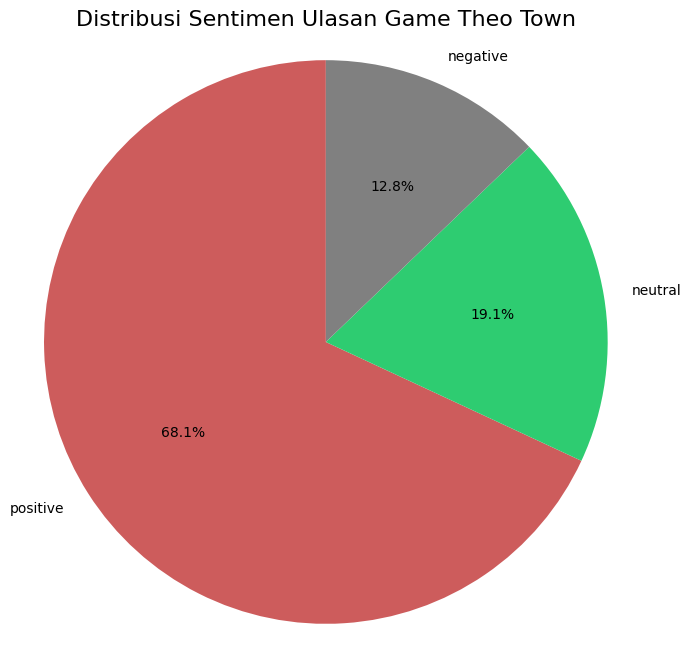

In [106]:
sentiment_counts = clean_df['polarity'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#CD5C5C','#2ECC71', '#808080'])
plt.title('Distribusi Sentimen Ulasan Game Theo Town', fontsize=16)
plt.axis('equal')
plt.show()

# EKSPLORASI LABEL (WORDCLOUD)

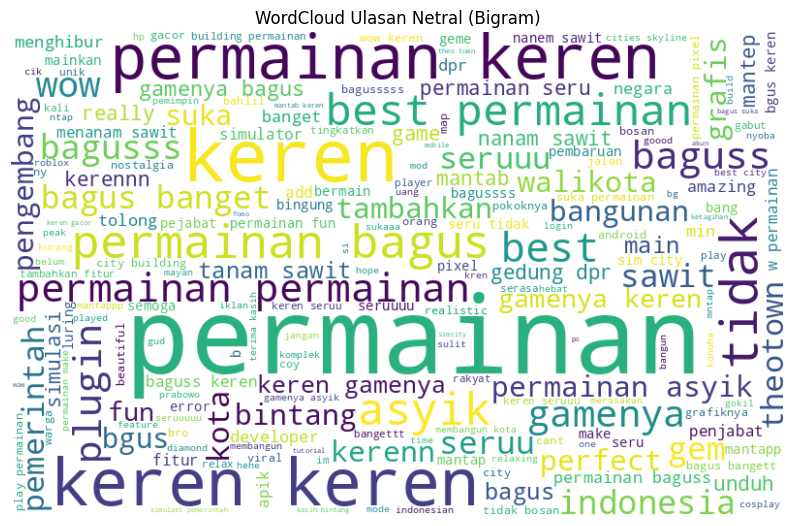

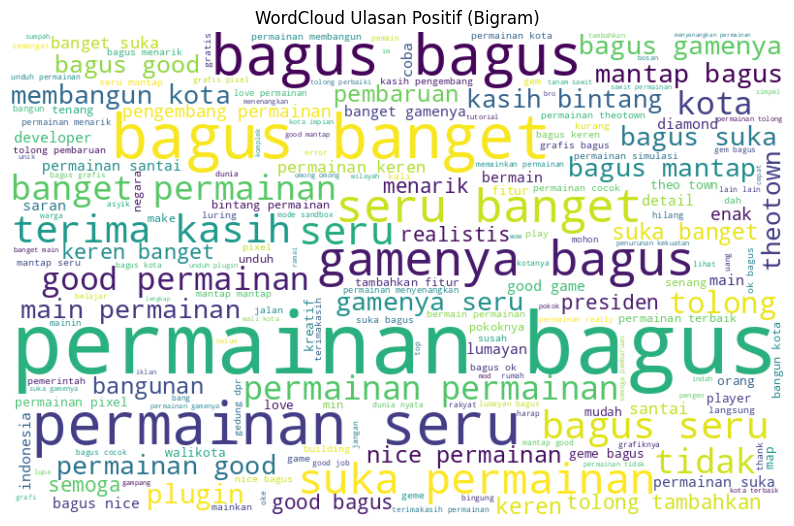

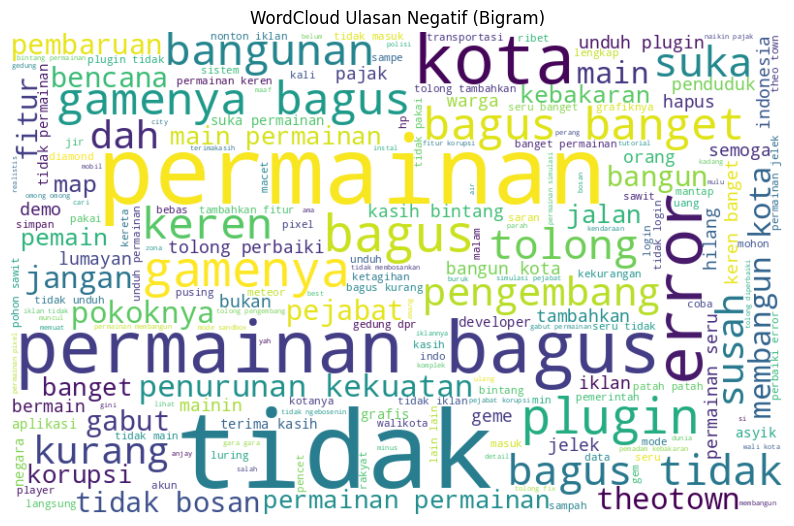

In [107]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc_config = {
    'width': 800,
    'height': 500,
    'random_state': 21,
    'max_font_size': 110,
    'background_color': 'white',
    'collocations': True,
    'collocation_threshold': 15
}

# (1) WordCloud untuk Neutral Tweets Data
neutral_words = ' '.join([text for text in clean_df['text_akhir'][clean_df['polarity'] == 'neutral']])
wordcloud_neutral = WordCloud(**wc_config).generate(neutral_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis('off')
plt.title('WordCloud Ulasan Netral (Bigram)')
plt.show()

# (2) WordCloud untuk Positive Tweets Data
positive_words = ' '.join([text for text in clean_df['text_akhir'][clean_df['polarity'] == 'positive']])
wordcloud_positive = WordCloud(**wc_config).generate(positive_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis('off')
plt.title('WordCloud Ulasan Positif (Bigram)')
plt.show()

# (3) WordCloud untuk Negative Tweets Data
negative_words = ' '.join([text for text in clean_df['text_akhir'][clean_df['polarity'] == 'negative']])
wordcloud_negative = WordCloud(**wc_config).generate(negative_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis('off')
plt.title('WordCloud Ulasan Negatif (Bigram)')
plt.show()

# DATA SPLITTING DAN EKSTRAKSI FITUR

In [108]:
# Tentukan Fitur dan Label
X = clean_df['text_akhir']
y = clean_df['polarity']

1. TF-IDF Untuk SVM

In [109]:
# Ekstraksi Fitur dengan TF-IDF (Fitur Skema 1)
tfidf_skema1 = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.8)
X_tfidf_skema1 = tfidf_skema1.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df_tfidf = pd.DataFrame(X_tfidf_skema1.toarray(), columns=tfidf_skema1.get_feature_names_out())

# Bagi data menjadi data latih dan data uji (Kombinasi 1: 80/20)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_tfidf_skema1, y, test_size=0.2, random_state=42)

print("Skema 1 Siap: TF-IDF dengan Split 80/20")
print(f"Jumlah data training: {X_train1.shape[0]}")
print(f"Jumlah data testing: {X_test1.shape[0]}")

# Karena Datanya Imnbalance dimana Positifnya cukup mendominasi, maka saya terapkan SMOTE pada data training
smote = SMOTE(random_state=42)
X_train1_resampled, y_train1_resampled = smote.fit_resample(X_train1, y_train1)
print("\n--- SETELAH BALANCING (SMOTE) ---")
print(f"Jumlah data training baru: {X_train1_resampled.shape[0]}")
print("Distribusi Kelas y_train baru:")
print(y_train1_resampled.value_counts())
print("\nSkema 1 Siap: TF-IDF dengan Split 80/20 & SMOTE")

Skema 1 Siap: TF-IDF dengan Split 80/20
Jumlah data training: 28403
Jumlah data testing: 7101

--- SETELAH BALANCING (SMOTE) ---
Jumlah data training baru: 57984
Distribusi Kelas y_train baru:
polarity
positive    19328
neutral     19328
negative    19328
Name: count, dtype: int64

Skema 1 Siap: TF-IDF dengan Split 80/20 & SMOTE


2. N-Gram untuk Random Forest

In [110]:
# Ekstraksi Fitur dengan N-Gram (Fitur Skema 2)
ngram_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=1000)
X_ngram = ngram_vectorizer.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df_ngram = pd.DataFrame(X_ngram.toarray(), columns=ngram_vectorizer.get_feature_names_out())

# Bagi data menjadi data latih dan data uji (Kombinasi 2: 90/10)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_ngram, y, test_size=0.1, random_state=42)

print("Skema 2 Siap: N-gram (1,2) dengan Split 90/10")
print(f"Jumlah data training: {X_train2.shape[0]}")
print(f"Jumlah data testing: {X_test2.shape[0]}")

# Karena Datanya Imnbalance dimana Positifnya cukup mendominasi, maka saya terapkan SMOTE pada data training
smote = SMOTE(random_state=42)
X_train2_resampled, y_train2_resampled = smote.fit_resample(X_train2, y_train2)
print("\n--- SETELAH BALANCING (SMOTE) ---")
print(f"Jumlah data training baru: {X_train2_resampled.shape[0]}")
print("Distribusi Kelas y_train baru:")
print(y_train2_resampled.value_counts())
print("\nSkema 2 Siap: N-Gram dengan Split 90/10 & SMOTE")

Skema 2 Siap: N-gram (1,2) dengan Split 90/10
Jumlah data training: 31953
Jumlah data testing: 3551

--- SETELAH BALANCING (SMOTE) ---
Jumlah data training baru: 65256
Distribusi Kelas y_train baru:
polarity
neutral     21752
positive    21752
negative    21752
Name: count, dtype: int64

Skema 2 Siap: N-Gram dengan Split 90/10 & SMOTE


3. BoW untuk Logistic Regression

In [111]:
# Ekstraksi Fitur dengan BoW (Fitur Skema 3)
bow_vectorizer = CountVectorizer(max_features=1000)
X_bow = bow_vectorizer.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())

# Bagi data menjadi data latih dan data uji (Kombinasi 3: 70/30)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_bow, y, test_size=0.3, random_state=42)

print("Skema 2 Siap: BoW dengan Split 70/30")
print(f"Jumlah data training: {X_train3.shape[0]}")
print(f"Jumlah data testing: {X_test3.shape[0]}")

# Karena Datanya Imnbalance dimana Positifnya cukup mendominasi, maka saya terapkan SMOTE pada data training
smote = SMOTE(random_state=42)
X_train3_resampled, y_train3_resampled = smote.fit_resample(X_train3, y_train3)
print("\n--- SETELAH BALANCING (SMOTE) ---")
print(f"Jumlah data training baru: {X_train3_resampled.shape[0]}")
print("Distribusi Kelas y_train baru:")
print(y_train3_resampled.value_counts())
print("\nSkema 1 Siap: BoW dengan Split 70/30 & SMOTE")

Skema 2 Siap: BoW dengan Split 70/30
Jumlah data training: 24852
Jumlah data testing: 10652

--- SETELAH BALANCING (SMOTE) ---
Jumlah data training baru: 50733
Distribusi Kelas y_train baru:
polarity
positive    16911
neutral     16911
negative    16911
Name: count, dtype: int64

Skema 1 Siap: BoW dengan Split 70/30 & SMOTE


# MODELLING

1. SVM

In [112]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Membuat objek model SVM
svm_model = LinearSVC()

# Melatih model SVM pada data pelatihan
svm_model.fit(X_train1_resampled, y_train1_resampled)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm = svm_model.predict(X_train1)
y_pred_test_svm = svm_model.predict(X_test1)

# Evaluasi akurasi model SVM
accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train1)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test1)

# Menampilkan akurasi
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)

SVM - accuracy_train: 0.9374361863183467
SVM - accuracy_test: 0.9270525278129841


2. Random Forest

In [113]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
random_forest = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train2_resampled, y_train2_resampled)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train2)
y_pred_test_rf = random_forest.predict(X_test2)

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train2)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test2)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9812537163959566
Random Forest - accuracy_test: 0.888200506899465


3. Logistic Regression

In [114]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
log_reg = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
log_reg.fit(X_train3_resampled, y_train3_resampled)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = log_reg.predict(X_train3)
y_pred_test_lr = log_reg.predict(X_test3)

# Evaluasi akurasi model Logistic Regression
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train3)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test3)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.937107677450507
Logistic Regression - accuracy_test: 0.9221742395794217


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Inference atau testing

In [116]:
# Data review baru
teks_baru = ["game tidak jelas"]

# Pre-processing
def preprocess_step(text):
    text = cleaningText(text)
    text = casefoldingText(text)
    text = fix_slangwords(text)
    tokens = tokenizingText(text)
    filtered_tokens = filteringText(tokens)
    text_for_stemming = toSentence(filtered_tokens)
    stemmed_text = stemmingText(text_for_stemming)
    return stemmed_text

teks_bersih = [preprocess_step(t) for t in teks_baru]

# Coba pakai 3 skema
svm_teks = tfidf_skema1.transform(teks_bersih)
rf_teks = ngram_vectorizer.transform(teks_bersih)
lr_teks = bow_vectorizer.transform(teks_bersih)

# Coba Prediksi
hasil_prediksi_svm = svm_model.predict(svm_teks)
hasil_prediksi_rf = random_forest.predict(rf_teks)
hasil_prediksi_lr = log_reg.predict(lr_teks)

# Tampilkan hasil prediski
print(f"Teks: {teks_baru[0]}")
print(f"Hasil Prediksi Kelas dengan SVM: {hasil_prediksi_svm[0]}")
print(f"Hasil Prediksi Kelas dengan RF: {hasil_prediksi_rf[0]}")
print(f"Hasil Prediksi Kelas dengan LR: {hasil_prediksi_lr[0]}")

Teks: game tidak jelas
Hasil Prediksi Kelas dengan SVM: negative
Hasil Prediksi Kelas dengan RF: negative
Hasil Prediksi Kelas dengan LR: negative
